**Importing necessary libraries**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Reading the data**

In [102]:
data=pd.read_csv("netflix_titles.csv")

**Reading first 5 rows**

In [103]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [104]:
data.shape

(8807, 12)

In [105]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


**Statistical measures**

In [106]:
data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


**Checking for null values**

In [107]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

**Handling and filling the null values**

In [108]:
data["director"] = data["director"].fillna("Unknown Director")
data["cast"] = data["cast"].fillna("Unknown cast")
data["country"] = data["country"].fillna("Unknown country")
data["rating"] = data["rating"].fillna(data["rating"].mode()[0])
data["date_added"] = data["date_added"].fillna(data["date_added"].mode()[0])
data["duration"] = data["duration"].fillna(data["duration"].mode()[0])

**Checking for null values after handling null values**

In [109]:
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Standardizing Column Names

In [110]:
data.columns=data.columns.str.lower().str.replace(' ','_')

**Counting content in columns**

In [112]:
data["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [113]:
data["director"].value_counts().head(10)

director
Unknown Director          2634
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Jay Chapman                 12
Name: count, dtype: int64

In [114]:
data["country"].value_counts().head(5)

country
United States      2818
India               972
Unknown country     831
United Kingdom      419
Japan               245
Name: count, dtype: int64

In [115]:
data["release_year"].value_counts().head(5)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64

In [116]:
data["duration"].value_counts().head(10)

duration
1 Season     1796
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64

In [117]:
idx = data[data["rating"].str.contains("min", na=False)].index
data.drop(idx, inplace=True)

In [118]:
data["rating"].value_counts().head(10)

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

**Checking for inconsistent years**

In [120]:
data[(data['release_year'] > 2025) | (data['release_year'] < 1900)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


**Content growth overtime**

In [121]:
data['year_added'] = pd.to_datetime(data['date_added'],errors='coerce').dt.year

data['year_added'].value_counts().sort_index()


year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     416
2017.0    1163
2018.0    1625
2019.0    1999
2020.0    1888
2021.0    1498
Name: count, dtype: int64

**Content gap between year added and release year**

In [122]:
data['gap_years'] = data['year_added'] - data['release_year']
data['gap_years'].describe()

count    8716.000000
mean        4.696306
std         8.791100
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: gap_years, dtype: float64

**Top countries producing content**

In [123]:
top_countries=data['country'].dropna().str.split(', ').explode().value_counts().head(10)
top_countries

country
United States      3686
India              1046
Unknown country     831
United Kingdom      804
Canada              445
France              393
Japan               318
Spain               232
South Korea         231
Germany             226
Name: count, dtype: int64

**Top genre of movies**

In [124]:
top_genres=data['listed_in'].str.split(', ').explode().value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

**Movies vs TV Shows**

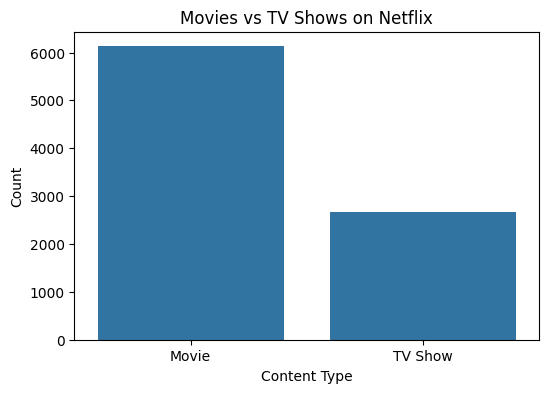

In [125]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='type')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

**Content Added Over the Years (Trend)**

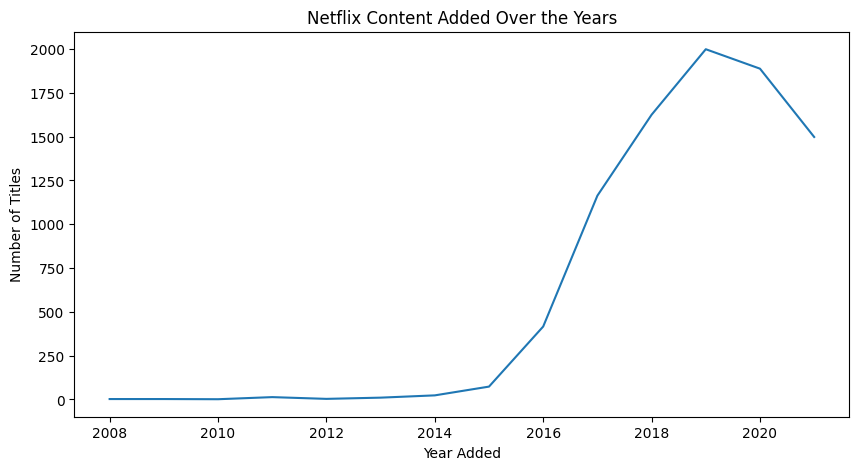

In [126]:
plt.figure(figsize=(10,5))
data['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

**Release Year Distribution**

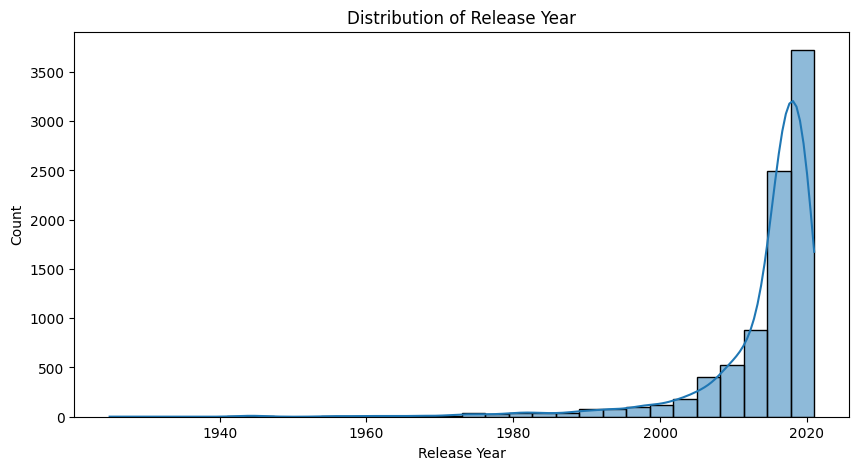

In [127]:
plt.figure(figsize=(10,5))
sns.histplot(data['release_year'],bins=30,kde=True)
plt.title("Distribution of Release Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.show()


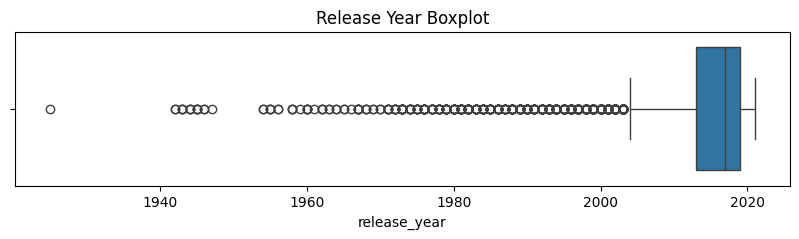

In [128]:
plt.figure(figsize=(10,2))
sns.boxplot(x=data['release_year'],orient='h')
plt.title("Release Year Boxplot")
plt.show()


**Top 10 Content Producing Countries**

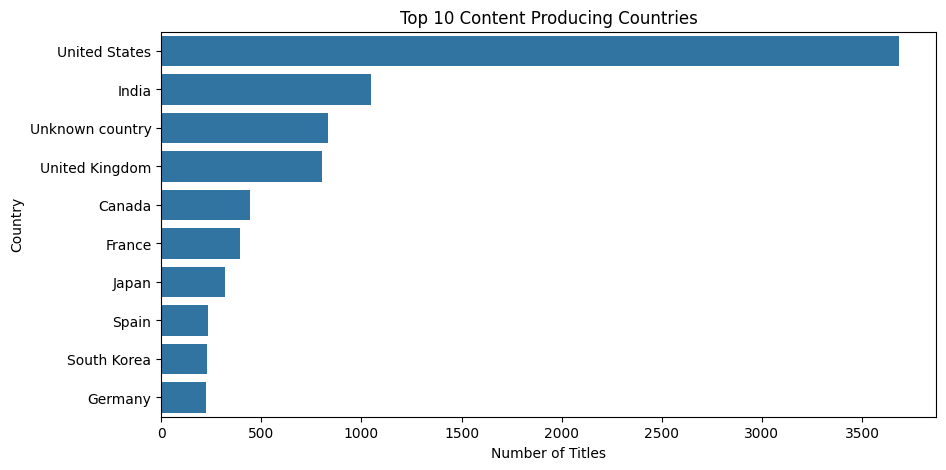

In [129]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values,y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

**Top 10 Genres on Netflix**

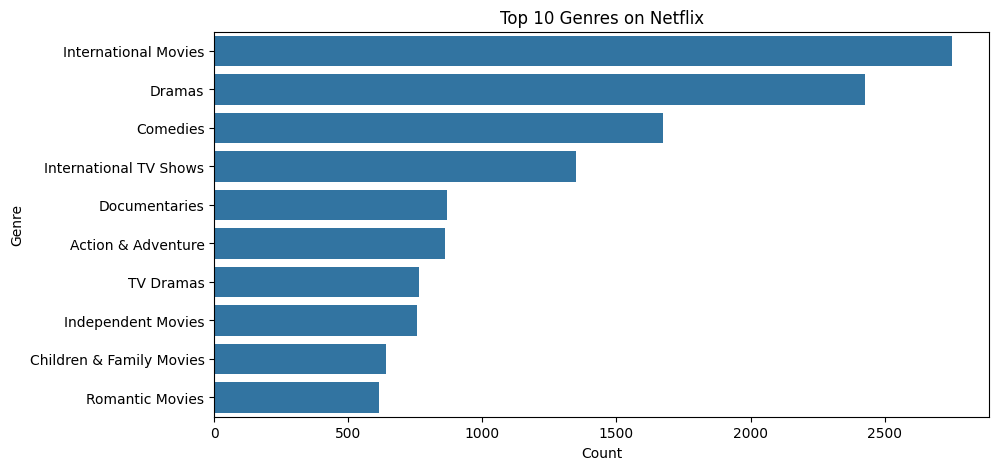

In [130]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

**Ratings Distribution**

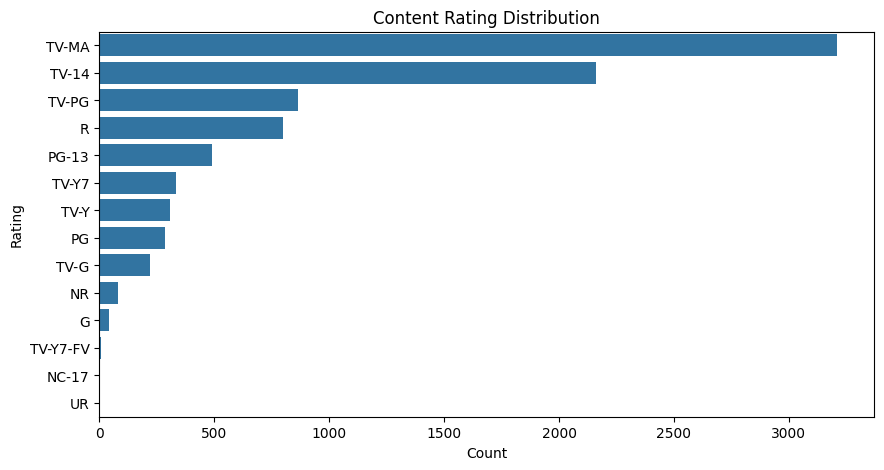

In [131]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, y='rating', order=data['rating'].value_counts().index)
plt.title("Content Rating Distribution")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.show()


**Gap Between Release Year & Netflix Addition**

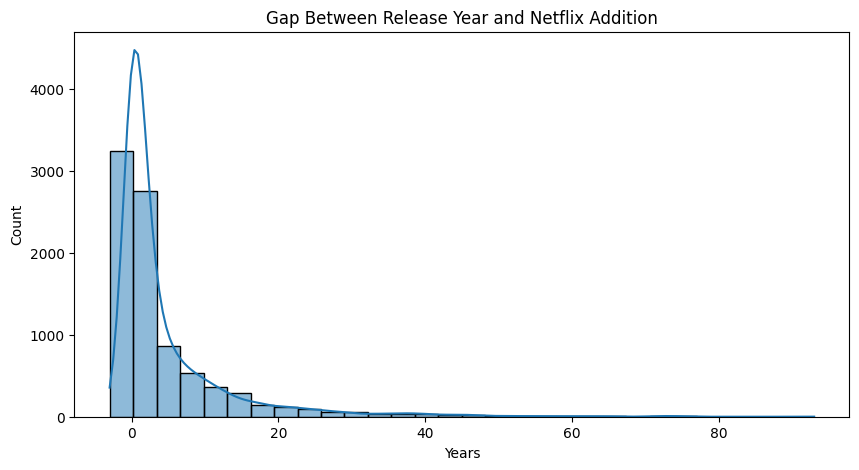

In [132]:
plt.figure(figsize=(10,5))
sns.histplot(data['gap_years'].dropna(),bins=30,kde=True)
plt.title("Gap Between Release Year and Netflix Addition")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show()



# 📊 Final Insights & Business Interpretation

## 🎬 Content Strategy
- Netflix has a significantly higher number of movies compared to TV shows.
- This suggests a focus on quick-consumption content, improving user engagement.

## 🌍 Geographic Distribution
- Majority of content is produced in the USA.
- Growing contribution from countries like India indicates global expansion strategy.

## 📈 Growth Trend
- Sharp increase in content addition after 2016.
- Indicates aggressive scaling phase and competition-driven expansion.

## ⭐ Audience Targeting
- Dominance of TV-MA rating shows focus on mature audiences.
- Netflix prioritizes adult-oriented storytelling.

## ⏱️ Duration Patterns
- Most movies fall between 90–120 minutes.
- Indicates optimization for standard viewing time.

## 🎭 Genre Insights
- Drama and Comedy are the most common genres.
- International content is rising, showing localization strategy.

## 🧠 Overall Conclusion
Netflix is focusing on:
- Scaling content library rapidly
- Targeting global audiences
- Prioritizing engagement-driven content
